In [ ]:
%pip install torch numpy matplotlib

In [1]:
import torch
import matplotlib.pyplot as plt

## Tensors

### Using Data

In [3]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print(x_data)

tensor([[1, 2],
        [3, 4]])


### Using Numpy Array

In [4]:
import numpy as np

np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)

tensor([[1, 2],
        [3, 4]])


### Using PyTorch Tensors

In [5]:
x_ones = torch.ones_like(x_np) # retains the properties of x_np
print(f"Ones Tensor: \n {x_ones} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 



In [6]:
x_rand = torch.rand_like(x_np, dtype=torch.float) # overrides the dtype of x_np to float
print(f"Random Tensor: \n {x_rand} \n")

Random Tensor: 
 tensor([[0.0701, 0.7272],
        [0.0158, 0.2178]]) 



In [7]:
shape = (2, 3, )
t_ones = torch.ones(shape)
t_zeros = torch.zeros(shape)
t_rand = torch.rand(shape)

### Tensor Attributes

In [8]:
t_rand.shape

torch.Size([2, 3])

In [9]:
t_ones.dtype

torch.float32

In [10]:
t_zeros.device

device(type='cpu')

In [11]:
x = torch.linspace(0, 5, 101)

In [12]:
x[-5:]

tensor([4.8000, 4.8500, 4.9000, 4.9500, 5.0000])

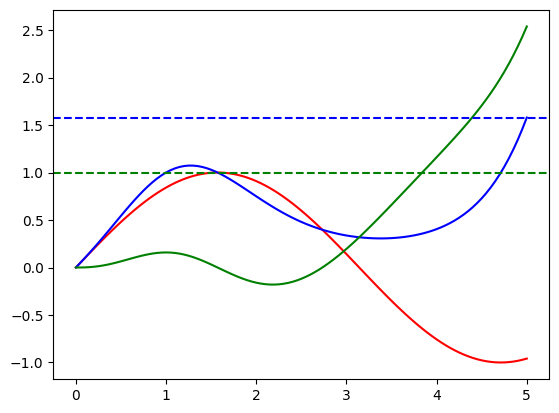

In [13]:
y1, y2 = x.sin(), x ** x.cos()
y3 = y2-y1
y4 = y1.max() # max, min, mean, standard deviation
y5 = y2.max()

plt.plot(x, y1, "red", x, y2, "blue", x, y3, "green")
plt.axhline(y4, color="green", linestyle="--")
plt.axhline(y5, color="blue", linestyle="--")
plt.show()

In [14]:
y4 = y3.clamp(0, 1)

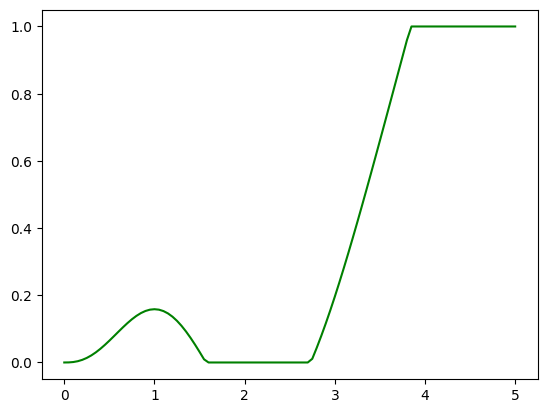

In [15]:
plt.plot(x, y4, "green")
plt.show()

### Batching

In [16]:
x = torch.rand([2, 3, 4, 5])
x.shape

torch.Size([2, 3, 4, 5])

In [17]:
x.permute(0, 1, 3, 2)[0][0][0]

tensor([0.6978, 0.4450, 0.8914, 0.7356])

In [18]:
x = torch.randn(2, 3, 4)
x.shape

torch.Size([2, 3, 4])

In [19]:
x[0] # first row

tensor([[ 0.2501,  1.7902,  1.4859, -0.3065],
        [-1.5650, -0.3452, -0.0548, -0.8964],
        [ 0.0820,  0.1371,  0.5452, -0.9411]])

In [20]:
x[:, 0] # first column

tensor([[ 0.2501,  1.7902,  1.4859, -0.3065],
        [-0.4260, -0.5635,  0.6697,  0.2758]])

In [21]:
x[:, -1] # last column

tensor([[ 0.0820,  0.1371,  0.5452, -0.9411],
        [ 1.1706,  0.3402,  0.1914, -0.6095]])

In [27]:
# reshape
x.view(x.shape[0], -1).shape

torch.Size([2, 12])

In [29]:
# assign values
x[:, 0] = 1
x

tensor([[[ 1.0000,  1.0000,  1.0000,  1.0000],
         [-1.5650, -0.3452, -0.0548, -0.8964],
         [ 0.0820,  0.1371,  0.5452, -0.9411]],

        [[ 1.0000,  1.0000,  1.0000,  1.0000],
         [-0.8983,  0.5038,  0.0085,  1.1889],
         [ 1.1706,  0.3402,  0.1914, -0.6095]]])

In [38]:
tensor = torch.linspace(0, 11, 12).reshape(3, 4)

In [48]:
# concat tensors
t1 = torch.cat([tensor, tensor], dim=1) # concatenate along columns
t2 = torch.cat([tensor, tensor], dim=0) # concatenate along rows
tensor.shape, t1.shape, t2.shape

(torch.Size([3, 4]), torch.Size([3, 8]), torch.Size([6, 4]))

In [49]:
# stack tensors: will give us a new dimension
t3 = torch.stack([tensor, tensor], dim=0) # stack along new dimension 0
t4 = torch.stack([tensor, tensor], dim=1) # stack along new dimension 1
tensor.shape, t3.shape, t4.shape

(torch.Size([3, 4]), torch.Size([2, 3, 4]), torch.Size([3, 2, 4]))

In [51]:
t3, t4

(tensor([[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]],
 
         [[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.]]]),
 tensor([[[ 0.,  1.,  2.,  3.],
          [ 0.,  1.,  2.,  3.]],
 
         [[ 4.,  5.,  6.,  7.],
          [ 4.,  5.,  6.,  7.]],
 
         [[ 8.,  9., 10., 11.],
          [ 8.,  9., 10., 11.]]]))

### Arithmetic Operations

In [52]:
tensor = torch.tensor([[1, 2], [3, 4]])
tensor.shape

torch.Size([2, 2])

In [65]:
# matrix multiplication
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
y3 = torch.ones(tensor.shape, dtype=torch.long)
torch.matmul(tensor, tensor.T, out=y3)
y1, y2, y3

(tensor([[ 5, 11],
         [11, 25]]),
 tensor([[ 5, 11],
         [11, 25]]),
 tensor([[ 5, 11],
         [11, 25]]))

In [72]:
# element wise multiplication
z1 = tensor * tensor
z2 = tensor.mul(tensor)
z3 = torch.ones(tensor.shape, dtype=torch.long)
torch.mul(tensor, tensor, out=z3)
z1, z2, z3

(tensor([[ 1,  4],
         [ 9, 16]]),
 tensor([[ 1,  4],
         [ 9, 16]]),
 tensor([[ 1,  4],
         [ 9, 16]]))

In [75]:
# Aggregation
agg = tensor.sum()
print(agg, agg.item(), type(agg), type(agg.item()))

tensor(10) 10 <class 'torch.Tensor'> <class 'int'>


## PyTorch Autograd

In [97]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()
s = y.sum()
[dydx] = torch.autograd.grad(s, [x])
dydx

tensor([-0.0000e+00, -2.5765e-04, -2.0612e-03, -6.9560e-03, -1.6485e-02,
        -3.2185e-02, -5.5575e-02, -8.8145e-02, -1.3133e-01, -1.8650e-01,
        -2.5487e-01, -3.3752e-01, -4.3528e-01, -5.4869e-01, -6.7791e-01,
        -8.2262e-01, -9.8193e-01, -1.1543e+00, -1.3373e+00, -1.5279e+00,
        -1.7218e+00, -1.9138e+00, -2.0978e+00, -2.2665e+00, -2.4118e+00,
        -2.5246e+00, -2.5954e+00, -2.6144e+00, -2.5720e+00, -2.4592e+00,
        -2.2684e+00, -1.9940e+00, -1.6330e+00, -1.1861e+00, -6.5843e-01,
        -5.9786e-02,  5.9438e-01,  1.2829e+00,  1.9791e+00,  2.6508e+00,
         3.2620e+00,  3.7737e+00,  4.1467e+00,  4.3434e+00,  4.3315e+00,
         4.0872e+00,  3.5983e+00,  2.8676e+00,  1.9159e+00,  7.8273e-01,
        -4.7262e-01, -1.7729e+00, -3.0265e+00, -4.1327e+00, -4.9894e+00,
        -5.5028e+00, -5.5970e+00, -5.2252e+00, -4.3782e+00, -3.0925e+00,
        -1.4526e+00,  4.1007e-01,  2.3249e+00,  4.0956e+00,  5.5192e+00,
         6.4094e+00,  6.6222e+00,  6.0798e+00,  4.7

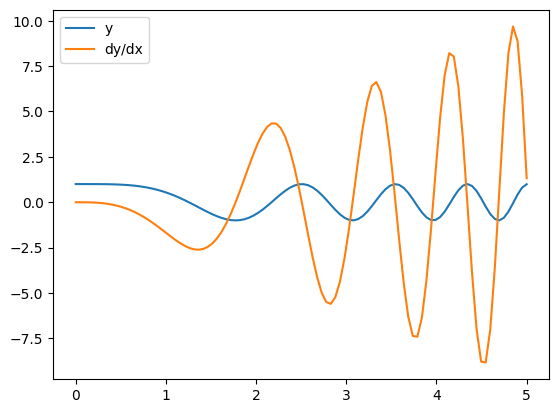

In [107]:
plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), dydx.detach(), label="dy/dx")
plt.legend()
plt.show()

In [110]:
## Polynomials x^3-6x^2+8x
x = torch.linspace(0, 5, 100, requires_grad=True)
y = x**3 - 6*(x**2) + 8*x

s = y.sum()
[dydx] = torch.autograd.grad(s, [x])
dydx

tensor([ 8.0000,  7.4016,  6.8185,  6.2507,  5.6982,  5.1610,  4.6391,  4.1325,
         3.6413,  3.1653,  2.7046,  2.2593,  1.8292,  1.4144,  1.0150,  0.6309,
         0.2620, -0.0915, -0.4298, -0.7527, -1.0603, -1.3526, -1.6296, -1.8913,
        -2.1377, -2.3688, -2.5846, -2.7851, -2.9703, -3.1402, -3.2948, -3.4340,
        -3.5580, -3.6667, -3.7600, -3.8381, -3.9008, -3.9483, -3.9804, -3.9972,
        -3.9988, -3.9850, -3.9559, -3.9115, -3.8519, -3.7769, -3.6866, -3.5810,
        -3.4601, -3.3238, -3.1723, -3.0055, -2.8234, -2.6260, -2.4132, -2.1852,
        -1.9418, -1.6832, -1.4092, -1.1200, -0.8154, -0.4956, -0.1604,  0.1901,
         0.5559,  0.9369,  1.3333,  1.7450,  2.1720,  2.6143,  3.0719,  3.5448,
         4.0331,  4.5366,  5.0554,  5.5895,  6.1390,  6.7037,  7.2837,  7.8791,
         8.4897,  9.1157,  9.7570, 10.4135, 11.0854, 11.7726, 12.4751, 13.1928,
        13.9259, 14.6743, 15.4380, 16.2170, 17.0113, 17.8209, 18.6459, 19.4861,
        20.3416, 21.2124, 22.0986, 23.00

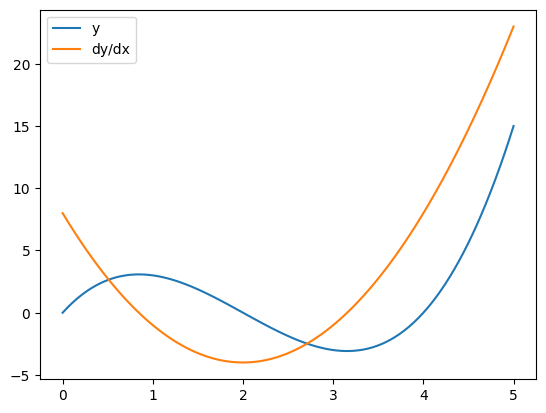

In [111]:
plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), dydx.detach(), label="dy/dx")
plt.legend()
plt.show()

## Back Propagation and In place Gradients

In [118]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()
print(x.grad)
y.sum().backward()
print(x.grad)

None
tensor([-0.0000e+00, -2.5765e-04, -2.0612e-03, -6.9560e-03, -1.6485e-02,
        -3.2185e-02, -5.5575e-02, -8.8145e-02, -1.3133e-01, -1.8650e-01,
        -2.5487e-01, -3.3752e-01, -4.3528e-01, -5.4869e-01, -6.7791e-01,
        -8.2262e-01, -9.8193e-01, -1.1543e+00, -1.3373e+00, -1.5279e+00,
        -1.7218e+00, -1.9138e+00, -2.0978e+00, -2.2665e+00, -2.4118e+00,
        -2.5246e+00, -2.5954e+00, -2.6144e+00, -2.5720e+00, -2.4592e+00,
        -2.2684e+00, -1.9940e+00, -1.6330e+00, -1.1861e+00, -6.5843e-01,
        -5.9786e-02,  5.9438e-01,  1.2829e+00,  1.9791e+00,  2.6508e+00,
         3.2620e+00,  3.7737e+00,  4.1467e+00,  4.3434e+00,  4.3315e+00,
         4.0872e+00,  3.5983e+00,  2.8676e+00,  1.9159e+00,  7.8273e-01,
        -4.7262e-01, -1.7729e+00, -3.0265e+00, -4.1327e+00, -4.9894e+00,
        -5.5028e+00, -5.5970e+00, -5.2252e+00, -4.3782e+00, -3.0925e+00,
        -1.4526e+00,  4.1007e-01,  2.3249e+00,  4.0956e+00,  5.5192e+00,
         6.4094e+00,  6.6222e+00,  6.0798e+00,

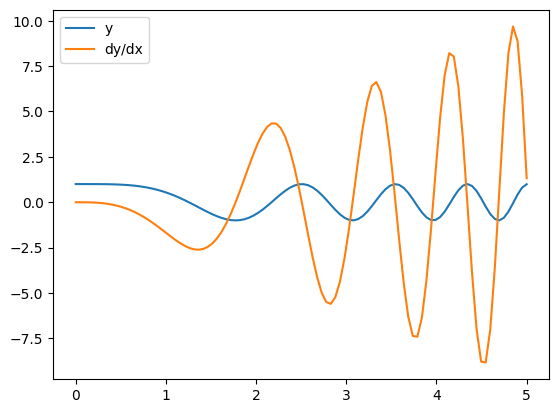

In [127]:
plt.plot(x.detach(), y.detach(), label="y")
plt.plot(x.detach(), x.grad, label="dy/dx")    
plt.legend()
plt.show()

## PyTorch Optimizers

In [ ]:
import torch

x = x_init.clone()
x.requires_grad = True

optimizer = torch.optim.SGD([x], lr=0.01, momentum=0.5)
bowl = torch.tensor([[0.4410, -1.0317], [-0.2844, -0.1035]])

track, losses = [], []

for iter in range(21):
    loss = torch.mm(bowl, x[:, None]).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.detach())

plot_progress(bowl, track, losses)

## Neural Network

In [2]:
# transformation from one dimension to another
net = torch.nn.Linear(4, 2)
print(net, net.weight, net.bias)

Linear(in_features=4, out_features=2, bias=True) Parameter containing:
tensor([[-0.1229, -0.0988,  0.4990, -0.4819],
        [ 0.1168, -0.1676, -0.3237,  0.0980]], requires_grad=True) Parameter containing:
tensor([-0.3230,  0.2936], requires_grad=True)


In [3]:
x = torch.tensor([[1.0, 2.0, 3.0, 4.0], [11.0, 12.0, 13.0, 14.0]])
net(x)

tensor([[-1.0741, -0.5038],
        [-3.1199, -3.2684]], grad_fn=<AddmmBackward0>)

In [4]:
x_batch = torch.cat([x, x*2, x*3, x*4], dim=0)
x_batch, net(x_batch)

(tensor([[ 1.,  2.,  3.,  4.],
         [11., 12., 13., 14.],
         [ 2.,  4.,  6.,  8.],
         [22., 24., 26., 28.],
         [ 3.,  6.,  9., 12.],
         [33., 36., 39., 42.],
         [ 4.,  8., 12., 16.],
         [44., 48., 52., 56.]]),
 tensor([[ -1.0741,  -0.5038],
         [ -3.1199,  -3.2684],
         [ -1.8252,  -1.3011],
         [ -5.9169,  -6.8303],
         [ -2.5763,  -2.0984],
         [ -8.7139, -10.3923],
         [ -3.3274,  -2.8957],
         [-11.5109, -13.9542]], grad_fn=<AddmmBackward0>))

In [6]:
print(f"Weight: {net.weight}, Bias: {net.bias}")

Weight: Parameter containing:
tensor([[-0.1229, -0.0988,  0.4990, -0.4819],
        [ 0.1168, -0.1676, -0.3237,  0.0980]], requires_grad=True), Bias: Parameter containing:
tensor([-0.3230,  0.2936], requires_grad=True)


In [7]:
with torch.no_grad():
    net.bias[:] = 0
    
print(net(x_batch))

tensor([[ -0.7511,  -0.7973],
        [ -2.7970,  -3.5619],
        [ -1.5022,  -1.5946],
        [ -5.5940,  -7.1239],
        [ -2.2533,  -2.3920],
        [ -8.3909, -10.6858],
        [ -3.0044,  -3.1893],
        [-11.1879, -14.2478]], grad_fn=<AddmmBackward0>)


In [8]:
for name, param in net.named_parameters():
    print(name, param.data)

weight tensor([[-0.1229, -0.0988,  0.4990, -0.4819],
        [ 0.1168, -0.1676, -0.3237,  0.0980]])
bias tensor([0., 0.])


In [15]:
for k, v in net.state_dict().items():
    print(f"{k}: {v.type()} {tuple(v.shape)}")

weight: torch.FloatTensor (2, 4)
bias: torch.FloatTensor (2,)


In [16]:
import os

os.makedirs("checkpoints", exist_ok=True)
torch.save(net.state_dict(), "checkpoints/linear.pth")

In [17]:
net.load_state_dict(torch.load("checkpoints/linear.pth"))

<All keys matched successfully>